# Social Media Engagement Intelligence & Prediction

## Project Objective

Analyze social media engagement patterns using Python and SQL, build a machine learning model to predict engagement performance, and develop a reproducible data-processing workflow.

## Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- MySQL
- SQLAlchemy

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##  Project Setup & Data Loading

In [5]:
# This loads the raw social media dataset into a Pandas DataFrame.

import pandas as pd

df = pd.read_csv("social_media_engagement_dataset.csv")

df.head()

,Post_ID,Timestamp,Platform,Content_Type,Category,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified
0,POST_04552,2024-01-01 01:42:00,Instagram,Carousel,Business,8287,247,51,29502,20,223080,3.85,1,Monday,16,985,Positive,Macro,True,False
1,POST_02171,2024-01-01 05:05:00,LinkedIn,Document,Health,1711,27,247,24538,139,312647,0.63,5,Monday,9,627,Negative,Macro,False,True
2,POST_00210,2024-01-01 09:18:00,Instagram,Carousel,Food,1527,191,7,5460,359,220737,0.78,9,Monday,27,79,Positive,Macro,True,True
3,POST_01548,2024-01-01 10:58:00,Facebook,Video,Sports,535,178,433,68246,740,428935,0.27,10,Monday,17,554,Neutral,Macro,True,False
4,POST_01350,2024-01-01 13:12:00,Instagram,Photo,Fitness,9706,35,118,25782,611,64384,15.31,13,Monday,5,1136,Positive,Mid-tier,True,False


##  Data Understanding

In [6]:
# This shows the number of rows and columns in our dataset.

df.shape

(5000, 20)

In [7]:
# This shows each column's data type and checks whether any values are missing.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   object 
 1   Timestamp        5000 non-null   object 
 2   Platform         5000 non-null   object 
 3   Content_Type     5000 non-null   object 
 4   Category         5000 non-null   object 
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   object 
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   object 
 17  Influencer_Tie

## Data Cleaning & Validation

In [8]:
# This counts the number of missing values in every column.

df.isnull().sum()

Post_ID            0
Timestamp          0
Platform           0
Content_Type       0
Category           0
Likes              0
Comments           0
Shares             0
Views              0
Saves              0
Follower_Count     0
Engagement_Rate    0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
dtype: int64

In [9]:
# This counts how many completely duplicated rows exist in the dataset.

df.duplicated().sum()

np.int64(0)

In [10]:
# This counts how many unique Post IDs exist in the dataset.

df["Post_ID"].nunique()

5000

In [11]:
# This shows the number of unique values in each categorical column.

categorical_columns = [
    "Platform",
    "Content_Type",
    "Category",
    "Day_of_Week",
    "Sentiment",
    "Influencer_Tier"
]

df[categorical_columns].nunique()

Platform            6
Content_Type       17
Category           12
Day_of_Week         7
Sentiment           3
Influencer_Tier     4
dtype: int64

In [12]:
# This displays the unique values present in each categorical column.

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


Platform:
['Instagram' 'LinkedIn' 'Facebook' 'Twitter' 'YouTube' 'TikTok']

Content_Type:
['Carousel' 'Document' 'Video' 'Photo' 'Poll' 'Thread' 'Live' 'Reel'
 'Post' 'Story' 'Short' 'Tweet' 'Retweet' 'Article' 'Duet' 'Stitch'
 'Community Post']

Category:
['Business' 'Health' 'Food' 'Sports' 'Fitness' 'Lifestyle' 'Education'
 'Travel' 'Entertainment' 'Technology' 'Gaming' 'Fashion']

Day_of_Week:
['Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday']

Sentiment:
['Positive' 'Negative' 'Neutral']

Influencer_Tier:
['Macro' 'Mid-tier' 'Micro' 'Nano']


In [13]:
# This shows how many records belong to each category.

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Platform ---
Platform
Instagram    1283
Twitter       994
Facebook      984
TikTok        758
LinkedIn      502
YouTube       479
Name: count, dtype: int64

--- Content_Type ---
Content_Type
Video             616
Story             568
Poll              384
Post              378
Live              358
Carousel          333
Photo             320
Reel              306
Stitch            259
Retweet           251
Duet              248
Tweet             239
Thread            236
Community Post    135
Document          132
Short             121
Article           116
Name: count, dtype: int64

--- Category ---
Category
Gaming           476
Technology       434
Lifestyle        433
Entertainment    432
Fashion          428
Food             413
Education        413
Sports           401
Travel           398
Health           397
Fitness          393
Business         382
Name: count, dtype: int64

--- Day_of_Week ---
Day_of_Week
Wednesday    727
Monday       719
Tuesday      717
Thursday     71

In [14]:
# This gives summary statistics for all numerical columns in the dataset.

df.describe()

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate,Hour_of_Day,Hashtag_Count,Content_Length
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7536.838400,339.898800,835.233400,110968.397000,753.150600,249959.204000,11.960148,11.562600,14.755800,754.508400
std,10169.129568,399.813585,1013.769853,181287.350216,932.653475,144592.908235,71.462053,6.946577,8.666117,576.334039
min,18.000000,1.000000,2.000000,527.000000,5.000000,543.000000,0.050000,0.000000,0.000000,15.000000
25%,1707.750000,96.000000,177.000000,18506.750000,200.000000,124560.250000,1.030000,5.000000,7.000000,280.000000
50%,4073.500000,212.000000,427.500000,40663.500000,424.000000,248930.500000,2.300000,12.000000,15.000000,549.000000
75%,7783.000000,377.000000,1111.500000,84226.750000,805.000000,374697.500000,6.245000,18.000000,22.000000,1226.250000
max,49949.000000,1999.000000,4997.000000,999256.000000,4985.000000,499815.000000,3510.460000,23.000000,29.000000,1999.000000


In [15]:
# This shows the posts with the highest engagement rates so we can understand why some values are extremely large.

df[["Likes", "Comments", "Shares", "Views", "Saves", "Follower_Count", "Engagement_Rate"]].sort_values(
    "Engagement_Rate", ascending=False
).head(10)

,Likes,Comments,Shares,Views,Saves,Follower_Count,Engagement_Rate
4615,42869,1208,2226,395527,1300,1319,3510.46
3918,45677,1232,4349,105146,2341,3840,1334.84
4129,8822,313,225,8815,957,857,1092.18
1846,44001,1515,531,136960,1073,4269,1078.64
4243,48254,720,1415,209674,1170,5102,987.63
3948,5723,356,111,34063,135,659,939.30
4807,7192,182,813,34546,525,1003,816.25
1693,38052,902,289,225696,2069,5443,720.98
4394,36683,633,597,347709,472,6134,618.08
4123,30501,773,2329,142702,2551,5541,606.44


In [16]:
# This calculates several possible engagement-rate formulas so we can identify how the dataset's Engagement_Rate was created.

df["calculated_rate_1"] = (
    (df["Likes"] + df["Comments"] + df["Shares"] + df["Saves"])
    / df["Follower_Count"]
) * 100

df["calculated_rate_2"] = (
    (df["Likes"] + df["Comments"] + df["Shares"])
    / df["Follower_Count"]
) * 100

df[[
    "Likes",
    "Comments",
    "Shares",
    "Saves",
    "Follower_Count",
    "Engagement_Rate",
    "calculated_rate_1",
    "calculated_rate_2"
]].head(10)

,Likes,Comments,Shares,Saves,Follower_Count,Engagement_Rate,calculated_rate_1,calculated_rate_2
0,8287,247,51,20,223080,3.85,3.857361,3.848395
1,1711,27,247,139,312647,0.63,0.679360,0.634901
2,1527,191,7,359,220737,0.78,0.944110,0.781473
3,535,178,433,740,428935,0.27,0.439694,0.267173
4,9706,35,118,611,64384,15.31,16.261804,15.312811
5,3767,83,522,242,421886,1.04,1.093660,1.036299
6,1558,71,676,92,259275,0.89,0.924501,0.889017
7,599,222,787,314,30966,5.19,6.206807,5.192792
8,6062,754,540,1640,395761,1.86,2.273089,1.858698
9,597,22,339,74,478824,0.20,0.215528,0.200074


## Feature Engineering

In [17]:
# This shows important percentiles of Engagement_Rate so we can choose a sensible threshold for high-engagement posts.

df["Engagement_Rate"].quantile([0.25, 0.50, 0.75, 0.90, 0.95])

0.25     1.030
0.50     2.300
0.75     6.245
0.90    17.208
0.95    34.596
Name: Engagement_Rate, dtype: float64

In [18]:
# This creates our machine-learning target: 1 for posts in the top 25% of engagement and 0 for the rest.

engagement_threshold = df["Engagement_Rate"].quantile(0.75)

df["High_Engagement"] = (
    df["Engagement_Rate"] >= engagement_threshold
).astype(int)

df["High_Engagement"].value_counts()

High_Engagement
0    3750
1    1250
Name: count, dtype: int64

In [19]:
# This creates a separate dataset containing only the features we will use for machine learning and our target variable.

ml_columns = [
    "Platform",
    "Content_Type",
    "Category",
    "Follower_Count",
    "Hour_of_Day",
    "Day_of_Week",
    "Hashtag_Count",
    "Content_Length",
    "Sentiment",
    "Influencer_Tier",
    "Has_Media",
    "Is_Verified",
    "High_Engagement"
]

ml_df = df[ml_columns].copy()

ml_df.head()

,Platform,Content_Type,Category,Follower_Count,Hour_of_Day,Day_of_Week,Hashtag_Count,Content_Length,Sentiment,Influencer_Tier,Has_Media,Is_Verified,High_Engagement
0,Instagram,Carousel,Business,223080,1,Monday,16,985,Positive,Macro,True,False,0
1,LinkedIn,Document,Health,312647,5,Monday,9,627,Negative,Macro,False,True,0
2,Instagram,Carousel,Food,220737,9,Monday,27,79,Positive,Macro,True,True,0
3,Facebook,Video,Sports,428935,10,Monday,17,554,Neutral,Macro,True,False,0
4,Instagram,Photo,Fitness,64384,13,Monday,5,1136,Positive,Mid-tier,True,False,1


In [20]:
# This checks the data types and missing values in our machine-learning dataset before preprocessing.

ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Platform         5000 non-null   object
 1   Content_Type     5000 non-null   object
 2   Category         5000 non-null   object
 3   Follower_Count   5000 non-null   int64 
 4   Hour_of_Day      5000 non-null   int64 
 5   Day_of_Week      5000 non-null   object
 6   Hashtag_Count    5000 non-null   int64 
 7   Content_Length   5000 non-null   int64 
 8   Sentiment        5000 non-null   object
 9   Influencer_Tier  5000 non-null   object
 10  Has_Media        5000 non-null   bool  
 11  Is_Verified      5000 non-null   bool  
 12  High_Engagement  5000 non-null   int64 
dtypes: bool(2), int64(5), object(6)
memory usage: 439.6+ KB


In [21]:
# This counts missing values in every feature of our machine-learning dataset.

ml_df.isnull().sum()

Platform           0
Content_Type       0
Category           0
Follower_Count     0
Hour_of_Day        0
Day_of_Week        0
Hashtag_Count      0
Content_Length     0
Sentiment          0
Influencer_Tier    0
Has_Media          0
Is_Verified        0
High_Engagement    0
dtype: int64

In [22]:
# This separates the input features (X) from the target variable (y) for machine learning.

X = ml_df.drop("High_Engagement", axis=1)
y = ml_df["High_Engagement"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 12)
y shape: (5000,)


In [23]:
# This splits the data into training and testing sets while preserving the 75%/25% target distribution.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 12)
X_test: (1000, 12)
y_train: (4000,)
y_test: (1000,)


In [24]:
# This separates categorical and numerical features so we can apply the correct preprocessing to each type.

categorical_features = [
    "Platform",
    "Content_Type",
    "Category",
    "Day_of_Week",
    "Sentiment",
    "Influencer_Tier"
]

numerical_features = [
    "Follower_Count",
    "Hour_of_Day",
    "Hashtag_Count",
    "Content_Length",
    "Has_Media",
    "Is_Verified"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Platform', 'Content_Type', 'Category', 'Day_of_Week', 'Sentiment', 'Influencer_Tier']
Numerical features: ['Follower_Count', 'Hour_of_Day', 'Hashtag_Count', 'Content_Length', 'Has_Media', 'Is_Verified']


## Machine Learning

In [25]:
# This creates a preprocessing pipeline that converts categorical features into numbers while keeping numerical features unchanged.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [26]:
# This creates our first machine-learning pipeline by combining feature preprocessing with a Logistic Regression classifier.

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


In [27]:
# This trains the Logistic Regression model using only the training data.

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


C:\Users\ganga\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
# This uses the trained model to predict whether each unseen post belongs to the high-engagement group.

y_pred = logistic_pipeline.predict(X_test)

print("Predictions created successfully.")
print("Number of predictions:", len(y_pred))

Predictions created successfully.
Number of predictions: 1000


In [29]:
# This calculates the accuracy of our Logistic Regression model on the unseen test data.

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 88.00%


## Model Evaluation

In [30]:
# This shows precision, recall, and F1-score for both engagement classes.

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Not High Engagement", "High Engagement"]
))

                     precision    recall  f1-score   support

Not High Engagement       0.92      0.92      0.92       750
    High Engagement       0.76      0.77      0.76       250

           accuracy                           0.88      1000
          macro avg       0.84      0.84      0.84      1000
       weighted avg       0.88      0.88      0.88      1000



In [31]:
# This creates a confusion matrix to show how many high- and non-high-engagement posts were classified correctly or incorrectly.

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[688  62]
 [ 58 192]]


In [32]:


# This calculates ROC-AUC to measure how well the model distinguishes high-engagement posts from other posts.

from sklearn.metrics import roc_auc_score

y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9514


In [33]:
# This creates our second machine-learning pipeline using the same preprocessing but a Random Forest classifier.

from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


In [34]:
# This trains the Random Forest model using only the training data.

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [35]:
# This uses the trained Random Forest model to predict high-engagement classes for the unseen test data.

y_pred_rf = random_forest_pipeline.predict(X_test)

print("Predictions created successfully.")
print("Number of predictions:", len(y_pred_rf))

Predictions created successfully.
Number of predictions: 1000


In [36]:
# This calculates the accuracy of the Random Forest model on the unseen test data.

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.2%}")

Random Forest Accuracy: 88.30%


In [37]:
# This shows precision, recall, and F1-score for the Random Forest model.

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Not High Engagement", "High Engagement"]
))

                     precision    recall  f1-score   support

Not High Engagement       0.93      0.91      0.92       750
    High Engagement       0.75      0.81      0.78       250

           accuracy                           0.88      1000
          macro avg       0.84      0.86      0.85      1000
       weighted avg       0.89      0.88      0.88      1000



In [38]:
# This calculates ROC-AUC to measure how well the Random Forest distinguishes high-engagement posts from other posts.

y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest ROC-AUC: {roc_auc_rf:.4f}")

Random Forest ROC-AUC: 0.9515


## Feature Importance

In [39]:
# This extracts the Random Forest feature importance values so we can understand which input features contributed most to the model's predictions.

rf_model = random_forest_pipeline.named_steps["model"]
rf_preprocessor = random_forest_pipeline.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
49,numerical__Follower_Count,0.189578
3,categorical__Platform_TikTok,0.140730
45,categorical__Influencer_Tier_Macro,0.116046
52,numerical__Content_Length,0.064020
46,categorical__Influencer_Tier_Micro,0.056447
51,numerical__Hashtag_Count,0.043098
50,numerical__Hour_of_Day,0.042038
18,categorical__Content_Type_Stitch,0.028030
10,categorical__Content_Type_Duet,0.024590
47,categorical__Influencer_Tier_Mid-tier,0.020992


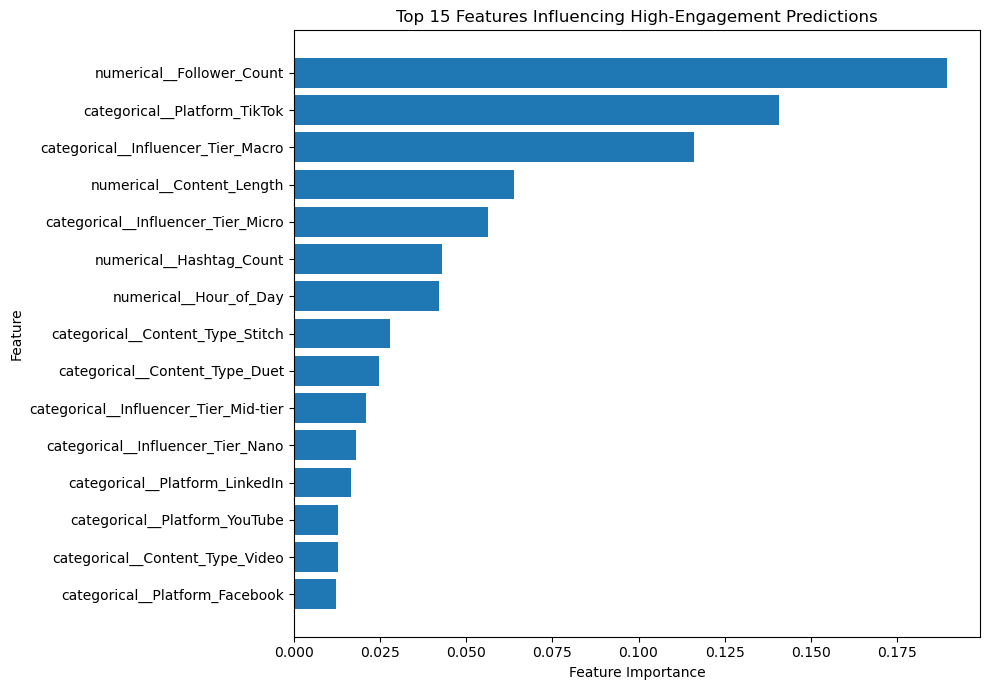

In [40]:
# This creates a horizontal bar chart showing the 15 features that contributed most to the Random Forest model.

import matplotlib.pyplot as plt

top_features = importance_df.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing High-Engagement Predictions")

plt.tight_layout()
plt.show()

In [41]:
# This shows how many high-engagement and non-high-engagement posts the Random Forest classified correctly and incorrectly.

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[681  69]
 [ 48 202]]


In [42]:
# This evaluates the Random Forest model across 5 different training and validation splits to check whether its performance is consistent.

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    random_forest_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross-validation ROC-AUC scores:", cv_scores)
print(f"Mean ROC-AUC: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")

Cross-validation ROC-AUC scores: [0.95534933 0.96009867 0.95089067 0.96406133 0.955456  ]
Mean ROC-AUC: 0.9572
Standard deviation: 0.0045


In [43]:
# This saves the complete Random Forest pipeline, including preprocessing and the trained model, so it can be reused later without retraining.

import joblib

joblib.dump(
    random_forest_pipeline,
    "social_media_engagement_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [44]:
# This loads the saved machine-learning pipeline and checks that it can make predictions correctly after being saved.

loaded_model = joblib.load("social_media_engagement_model.pkl")

test_predictions = loaded_model.predict(X_test)

print("Model loaded successfully.")
print("Predictions created:", len(test_predictions))
print("Predictions match original model:",
      (test_predictions == y_pred_rf).all())

Model loaded successfully.
Predictions created: 1000
Predictions match original model: True


In [45]:
# This checks the final cleaned dataset before we load it into MySQL.

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

Rows: 5000
Columns: 23

Column names:
['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Follower_Count', 'Engagement_Rate', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified', 'calculated_rate_1', 'calculated_rate_2', 'High_Engagement']


In [46]:
# This removes the two temporary engagement-rate calculation columns that we created during data investigation.

df = df.drop(
    columns=["calculated_rate_1", "calculated_rate_2"]
)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nColumn names:")
print(df.columns.tolist())

Rows: 5000
Columns: 21

Column names:
['Post_ID', 'Timestamp', 'Platform', 'Content_Type', 'Category', 'Likes', 'Comments', 'Shares', 'Views', 'Saves', 'Follower_Count', 'Engagement_Rate', 'Hour_of_Day', 'Day_of_Week', 'Hashtag_Count', 'Content_Length', 'Sentiment', 'Influencer_Tier', 'Has_Media', 'Is_Verified', 'High_Engagement']


In [47]:
# This checks the data types of all final columns so we can map them correctly to MySQL data types.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Post_ID          5000 non-null   object 
 1   Timestamp        5000 non-null   object 
 2   Platform         5000 non-null   object 
 3   Content_Type     5000 non-null   object 
 4   Category         5000 non-null   object 
 5   Likes            5000 non-null   int64  
 6   Comments         5000 non-null   int64  
 7   Shares           5000 non-null   int64  
 8   Views            5000 non-null   int64  
 9   Saves            5000 non-null   int64  
 10  Follower_Count   5000 non-null   int64  
 11  Engagement_Rate  5000 non-null   float64
 12  Hour_of_Day      5000 non-null   int64  
 13  Day_of_Week      5000 non-null   object 
 14  Hashtag_Count    5000 non-null   int64  
 15  Content_Length   5000 non-null   int64  
 16  Sentiment        5000 non-null   object 
 17  Influencer_Tie

In [48]:
# This converts the Timestamp column from text into a proper datetime format so it can be stored and analyzed correctly in MySQL.

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(df["Timestamp"].dtype)
print(df["Timestamp"].head())

datetime64[ns]
0   2024-01-01 01:42:00
1   2024-01-01 05:05:00
2   2024-01-01 09:18:00
3   2024-01-01 10:58:00
4   2024-01-01 13:12:00
Name: Timestamp, dtype: datetime64[ns]


In [49]:
# This performs a final check for missing values and duplicate rows before loading the dataset into MySQL.

print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Unique Post_IDs:", df["Post_ID"].nunique())
print("Total rows:", len(df))

Total missing values: 0
Duplicate rows: 0
Unique Post_IDs: 5000
Total rows: 5000


## MySQL Data Preparation & ETL

In [51]:
# This installs the MySQL connector package so Python can communicate with MySQL.

%pip install mysql-connector-python

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
   - -------------------------------------- 0.8/17.7 MB 7.0 MB/s eta 0:00:03
   --- ------------------------------------ 1.6/17.7 MB 3.2 MB/s eta 0:00:06
   ----- ---------------------------------- 2.4/17.7 MB 3.6 MB/s eta 0:00:05
   ------- -------------------------------- 3.1/17.7 MB 3.4 MB/s eta 0:00:05
   ------- -------------------------------- 3.1/17.7 MB 3.4 MB/s eta 0:00:05
   ------- -------------------------------- 3.4/17.7 MB 2.6 MB/s eta 0:00:06
   -------- ------------------------------- 3.9/17.7 MB 2.6 MB/s eta 0:00:06
   ----------- ---------------------------- 5.0/17.7 MB 2.9 MB/s eta 0:00:05
   ------------- -------------------------- 6.0/17.7 MB 3.0 MB/s eta 0:00:04
   -------------- ------------------------- 6.6/17.7 MB 3.0 MB/s eta 0:00:04
   --------------- ------------------------ 6.8/17.7 MB 3.0 MB/s eta 0:00:04
   ----------

In [52]:
# This imports the MySQL connector library so Python can connect to our MySQL database.

import mysql.connector

print("MySQL connector imported successfully.")

MySQL connector imported successfully.


In [53]:
# This connects Python to your local MySQL server so we can load the cleaned social media dataset into a database.

import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sql_password"
)

print("MySQL connection successful.")

MySQL connection successful.


In [54]:
# This creates a separate MySQL database for the Social Media Engagement project.

cursor = connection.cursor()

cursor.execute("""
CREATE DATABASE IF NOT EXISTS social_media_analysis
""")

print("Database created successfully.")

Database created successfully.


In [55]:
# This connects Python directly to the Social Media Analysis database we just created.

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="sql_password",
    database="social_media_analysis"
)

cursor = connection.cursor()

print("Connected to social_media_analysis successfully.")

Connected to social_media_analysis successfully.


## SQL Analytics

In [56]:
# This creates the MySQL table that will store our 5,000 cleaned social-media posts.

create_table_query = """
CREATE TABLE IF NOT EXISTS social_media_posts (
    Post_ID VARCHAR(50) PRIMARY KEY,
    Timestamp DATETIME,
    Platform VARCHAR(50),
    Content_Type VARCHAR(50),
    Category VARCHAR(50),
    Likes INT,
    Comments INT,
    Shares INT,
    Views INT,
    Saves INT,
    Follower_Count INT,
    Engagement_Rate DECIMAL(10,2),
    Hour_of_Day INT,
    Day_of_Week VARCHAR(20),
    Hashtag_Count INT,
    Content_Length INT,
    Sentiment VARCHAR(20),
    Influencer_Tier VARCHAR(20),
    Has_Media BOOLEAN,
    Is_Verified BOOLEAN,
    High_Engagement INT
)
"""

cursor.execute(create_table_query)
connection.commit()

print("Table created successfully.")

Table created successfully.


In [57]:
# This inserts all 5,000 cleaned social-media posts from the pandas dataframe into our MySQL table.

insert_query = """
INSERT INTO social_media_posts (
    Post_ID,
    Timestamp,
    Platform,
    Content_Type,
    Category,
    Likes,
    Comments,
    Shares,
    Views,
    Saves,
    Follower_Count,
    Engagement_Rate,
    Hour_of_Day,
    Day_of_Week,
    Hashtag_Count,
    Content_Length,
    Sentiment,
    Influencer_Tier,
    Has_Media,
    Is_Verified,
    High_Engagement
)
VALUES (
    %s, %s, %s, %s, %s, %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s
)
"""

data = [
    tuple(row)
    for row in df.itertuples(index=False, name=None)
]

cursor.executemany(insert_query, data)
connection.commit()

print("Rows inserted:", cursor.rowcount)

Rows inserted: 5000


In [58]:
# This verifies how many records were successfully loaded into the MySQL table.

cursor.execute("""
SELECT COUNT(*) 
FROM social_media_posts
""")

row_count = cursor.fetchone()[0]

print("Rows in MySQL:", row_count)

Rows in MySQL: 5000


In [59]:
# This checks the first 10 records in MySQL to verify that the loaded data looks correct.

cursor.execute("""
SELECT *
FROM social_media_posts
LIMIT 10
""")

rows = cursor.fetchall()

for row in rows:
    print(row)

('POST_00001', datetime.datetime(2025, 10, 16, 3, 1), 'Twitter', 'Tweet', 'Food', 3457, 95, 1401, 93498, 441, 24228, Decimal('20.44'), 3, 'Thursday', 18, 585, 'Positive', 'Micro', 1, 0, 1)
('POST_00002', datetime.datetime(2024, 10, 8, 7, 14), 'YouTube', 'Live', 'Business', 9601, 668, 1525, 123772, 59, 361800, Decimal('3.26'), 7, 'Tuesday', 10, 161, 'Neutral', 'Macro', 1, 0, 0)
('POST_00003', datetime.datetime(2024, 5, 22, 23, 6), 'LinkedIn', 'Article', 'Entertainment', 1392, 62, 255, 24449, 249, 424158, Decimal('0.40'), 23, 'Wednesday', 29, 623, 'Neutral', 'Macro', 1, 1, 0)
('POST_00004', datetime.datetime(2025, 11, 23, 23, 57), 'Facebook', 'Post', 'Food', 1930, 172, 694, 75111, 466, 87346, Decimal('3.20'), 23, 'Sunday', 20, 1532, 'Neutral', 'Mid-tier', 1, 0, 0)
('POST_00005', datetime.datetime(2025, 7, 12, 2, 37), 'Instagram', 'Reel', 'Education', 865, 432, 174, 15566, 473, 305165, Decimal('0.48'), 2, 'Saturday', 10, 81, 'Positive', 'Macro', 1, 0, 0)
('POST_00006', datetime.datetime(2

In [60]:
# This compares platforms by number of posts and average engagement rate.
# Platform Performance

cursor.execute("""
SELECT
    Platform,
    COUNT(*) AS Total_Posts,
    ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate
FROM social_media_posts
GROUP BY Platform
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', 758, Decimal('41.83'))
('YouTube', 479, Decimal('10.46'))
('Instagram', 1283, Decimal('8.12'))
('Facebook', 984, Decimal('7.17'))
('Twitter', 994, Decimal('4.76'))
('LinkedIn', 502, Decimal('1.75'))


In [61]:
# This compares content categories by the number of posts and their average engagement rate.
# Category Performance
cursor.execute("""
SELECT
    Category,
    COUNT(*) AS Total_Posts,
    ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate
FROM social_media_posts
GROUP BY Category
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Lifestyle', 433, Decimal('19.13'))
('Travel', 398, Decimal('15.21'))
('Technology', 434, Decimal('13.96'))
('Food', 413, Decimal('12.95'))
('Business', 382, Decimal('11.96'))
('Education', 413, Decimal('11.89'))
('Entertainment', 432, Decimal('11.57'))
('Fitness', 393, Decimal('10.38'))
('Gaming', 476, Decimal('9.91'))
('Sports', 401, Decimal('9.54'))
('Health', 397, Decimal('9.32'))
('Fashion', 428, Decimal('7.61'))


In [62]:
# This calculates the number and percentage of high-engagement posts for each platform.

cursor.execute("""
SELECT
    Platform,
    COUNT(*) AS Total_Posts,
    SUM(High_Engagement) AS High_Engagement_Posts,
    ROUND(
        100.0 * SUM(High_Engagement) / COUNT(*),
        2
    ) AS High_Engagement_Percentage
FROM social_media_posts
GROUP BY Platform
ORDER BY High_Engagement_Percentage DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', 758, Decimal('563'), Decimal('74.27'))
('YouTube', 479, Decimal('157'), Decimal('32.78'))
('Instagram', 1283, Decimal('223'), Decimal('17.38'))
('Facebook', 984, Decimal('159'), Decimal('16.16'))
('Twitter', 994, Decimal('125'), Decimal('12.58'))
('LinkedIn', 502, Decimal('23'), Decimal('4.58'))


In [63]:
#Content Type Analysis
# This compares different content types using post volume and average engagement rate.

cursor.execute("""
SELECT
    Content_Type,
    COUNT(*) AS Total_Posts,
    ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate
FROM social_media_posts
GROUP BY Content_Type
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Stitch', 259, Decimal('45.38'))
('Duet', 248, Decimal('41.63'))
('Video', 616, Decimal('20.41'))
('Reel', 306, Decimal('11.67'))
('Short', 121, Decimal('10.74'))
('Community Post', 135, Decimal('10.19'))
('Carousel', 333, Decimal('8.38'))
('Post', 378, Decimal('7.71'))
('Live', 358, Decimal('7.41'))
('Tweet', 239, Decimal('6.30'))
('Photo', 320, Decimal('6.28'))
('Story', 568, Decimal('5.92'))
('Thread', 236, Decimal('4.83'))
('Retweet', 251, Decimal('3.75'))
('Poll', 384, Decimal('3.28'))
('Article', 116, Decimal('1.45'))
('Document', 132, Decimal('1.18'))


In [64]:
# This uses CASE to classify each post into Low, Medium, or High engagement based on our dataset thresholds.

cursor.execute("""
SELECT
    CASE
        WHEN Engagement_Rate >= 6.245 THEN 'High'
        WHEN Engagement_Rate >= 2.30 THEN 'Medium'
        ELSE 'Low'
    END AS Engagement_Level,
    COUNT(*) AS Total_Posts
FROM social_media_posts
GROUP BY Engagement_Level
ORDER BY
    CASE
        WHEN Engagement_Level = 'High' THEN 1
        WHEN Engagement_Level = 'Medium' THEN 2
        ELSE 3
    END
""")

results = cursor.fetchall()

for row in results:
    print(row)

('High', 1250)
('Medium', 1251)
('Low', 2499)


In [65]:
# This finds content types whose average engagement rate is above 10 and that have at least 200 posts.

cursor.execute("""
SELECT
    Content_Type,
    COUNT(*) AS Total_Posts,
    ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate
FROM social_media_posts
GROUP BY Content_Type
HAVING AVG(Engagement_Rate) > 10
   AND COUNT(*) >= 200
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Stitch', 259, Decimal('45.38'))
('Duet', 248, Decimal('41.63'))
('Video', 616, Decimal('20.41'))
('Reel', 306, Decimal('11.67'))


In [66]:
# This calculates the average engagement rate for each platform using only verified posts.

cursor.execute("""
SELECT
    Platform,
    COUNT(*) AS Verified_Posts,
    ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate
FROM social_media_posts
WHERE Is_Verified = 1
GROUP BY Platform
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', 197, Decimal('42.20'))
('Instagram', 310, Decimal('9.56'))
('Facebook', 265, Decimal('8.61'))
('YouTube', 140, Decimal('8.06'))
('Twitter', 251, Decimal('5.44'))
('LinkedIn', 144, Decimal('1.86'))


In [67]:
# This compares the number of verified and non-verified posts and their average engagement rates.

cursor.execute("""
SELECT
    CASE
        WHEN Is_Verified = 1 THEN 'Verified'
        ELSE 'Not Verified'
    END AS Verification_Status,
    COUNT(*) AS Total_Posts,
    ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate
FROM social_media_posts
GROUP BY Is_Verified
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Verified', 1307, Decimal('12.49'))
('Not Verified', 3693, Decimal('11.77'))


In [68]:
# This counts verified and non-verified posts separately for each platform using conditional aggregation.

cursor.execute("""
SELECT
    Platform,
    COUNT(*) AS Total_Posts,
    SUM(CASE WHEN Is_Verified = 1 THEN 1 ELSE 0 END) AS Verified_Posts,
    SUM(CASE WHEN Is_Verified = 0 THEN 1 ELSE 0 END) AS Not_Verified_Posts
FROM social_media_posts
GROUP BY Platform
ORDER BY Total_Posts DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Instagram', 1283, Decimal('310'), Decimal('973'))
('Twitter', 994, Decimal('251'), Decimal('743'))
('Facebook', 984, Decimal('265'), Decimal('719'))
('TikTok', 758, Decimal('197'), Decimal('561'))
('LinkedIn', 502, Decimal('144'), Decimal('358'))
('YouTube', 479, Decimal('140'), Decimal('339'))


In [69]:
# This calculates the percentage of posts that are verified for each platform.

cursor.execute("""
SELECT
    Platform,
    COUNT(*) AS Total_Posts,
    SUM(CASE WHEN Is_Verified = 1 THEN 1 ELSE 0 END) AS Verified_Posts,
    ROUND(
        100.0 * SUM(CASE WHEN Is_Verified = 1 THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS Verified_Percentage
FROM social_media_posts
GROUP BY Platform
ORDER BY Verified_Percentage DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('YouTube', 479, Decimal('140'), Decimal('29.23'))
('LinkedIn', 502, Decimal('144'), Decimal('28.69'))
('Facebook', 984, Decimal('265'), Decimal('26.93'))
('TikTok', 758, Decimal('197'), Decimal('25.99'))
('Twitter', 994, Decimal('251'), Decimal('25.25'))
('Instagram', 1283, Decimal('310'), Decimal('24.16'))


In [70]:
# This counts total posts, verified posts, and verified posts that achieved high engagement for each platform.

cursor.execute("""
SELECT
    Platform,
    COUNT(*) AS Total_Posts,
    SUM(CASE WHEN Is_Verified = 1 THEN 1 ELSE 0 END) AS Verified_Posts,
    SUM(CASE
        WHEN Is_Verified = 1 AND High_Engagement = 1 THEN 1
        ELSE 0
    END) AS Verified_High_Engagement_Posts
FROM social_media_posts
GROUP BY Platform
ORDER BY Verified_High_Engagement_Posts DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', 758, Decimal('197'), Decimal('144'))
('Instagram', 1283, Decimal('310'), Decimal('55'))
('YouTube', 479, Decimal('140'), Decimal('42'))
('Facebook', 984, Decimal('265'), Decimal('40'))
('Twitter', 994, Decimal('251'), Decimal('37'))
('LinkedIn', 502, Decimal('144'), Decimal('6'))


In [71]:
# This calculates the percentage of verified posts that achieved high engagement for each platform.

cursor.execute("""
SELECT
    Platform,
    SUM(CASE WHEN Is_Verified = 1 THEN 1 ELSE 0 END) AS Verified_Posts,
    SUM(CASE
        WHEN Is_Verified = 1 AND High_Engagement = 1 THEN 1
        ELSE 0
    END) AS Verified_High_Engagement_Posts,
    ROUND(
        100.0 *
        SUM(CASE
            WHEN Is_Verified = 1 AND High_Engagement = 1 THEN 1
            ELSE 0
        END)
        /
        SUM(CASE WHEN Is_Verified = 1 THEN 1 ELSE 0 END),
        2
    ) AS High_Engagement_Percentage
FROM social_media_posts
GROUP BY Platform
ORDER BY High_Engagement_Percentage DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', Decimal('197'), Decimal('144'), Decimal('73.10'))
('YouTube', Decimal('140'), Decimal('42'), Decimal('30.00'))
('Instagram', Decimal('310'), Decimal('55'), Decimal('17.74'))
('Facebook', Decimal('265'), Decimal('40'), Decimal('15.09'))
('Twitter', Decimal('251'), Decimal('37'), Decimal('14.74'))
('LinkedIn', Decimal('144'), Decimal('6'), Decimal('4.17'))


In [72]:
# This finds posts whose engagement rate is higher than the overall average engagement rate using a subquery.

cursor.execute("""
SELECT
    Post_ID,
    Platform,
    Content_Type,
    Engagement_Rate
FROM social_media_posts
WHERE Engagement_Rate > (
    SELECT AVG(Engagement_Rate)
    FROM social_media_posts
)
ORDER BY Engagement_Rate DESC
LIMIT 10
""")

results = cursor.fetchall()

for row in results:
    print(row)

('POST_02510', 'TikTok', 'Stitch', Decimal('3510.46'))
('POST_02248', 'TikTok', 'Video', Decimal('1334.84'))
('POST_01362', 'Instagram', 'Reel', Decimal('1092.18'))
('POST_01478', 'TikTok', 'Duet', Decimal('1078.64'))
('POST_01373', 'TikTok', 'Stitch', Decimal('987.63'))
('POST_03870', 'Instagram', 'Reel', Decimal('939.30'))
('POST_01501', 'Facebook', 'Video', Decimal('816.25'))
('POST_02569', 'TikTok', 'Video', Decimal('720.98'))
('POST_01874', 'TikTok', 'Duet', Decimal('618.08'))
('POST_03002', 'TikTok', 'Duet', Decimal('606.44'))


In [73]:
# This finds platforms whose average engagement rate is higher than the overall average engagement rate.

cursor.execute("""
SELECT
    Platform,
    COUNT(*) AS Total_Posts,
    ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate
FROM social_media_posts
GROUP BY Platform
HAVING AVG(Engagement_Rate) > (
    SELECT AVG(Engagement_Rate)
    FROM social_media_posts
)
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', 758, Decimal('41.83'))


In [74]:
# This finds the highest-engagement post within each platform using the ROW_NUMBER window function.

cursor.execute("""
SELECT
    Post_ID,
    Platform,
    Content_Type,
    Engagement_Rate
FROM (
    SELECT
        Post_ID,
        Platform,
        Content_Type,
        Engagement_Rate,
        ROW_NUMBER() OVER (
            PARTITION BY Platform
            ORDER BY Engagement_Rate DESC
        ) AS row_num
    FROM social_media_posts
) AS ranked_posts
WHERE row_num = 1
ORDER BY Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('POST_02510', 'TikTok', 'Stitch', Decimal('3510.46'))
('POST_01362', 'Instagram', 'Reel', Decimal('1092.18'))
('POST_01501', 'Facebook', 'Video', Decimal('816.25'))
('POST_03404', 'Twitter', 'Tweet', Decimal('511.34'))
('POST_03516', 'YouTube', 'Short', Decimal('305.46'))
('POST_01889', 'LinkedIn', 'Post', Decimal('84.58'))


In [75]:
# This ranks posts within each platform by engagement rate and returns the top 3 ranks from every platform.

cursor.execute("""
SELECT
    Post_ID,
    Platform,
    Content_Type,
    Engagement_Rate,
    post_rank
FROM (
    SELECT
        Post_ID,
        Platform,
        Content_Type,
        Engagement_Rate,
        RANK() OVER (
            PARTITION BY Platform
            ORDER BY Engagement_Rate DESC
        ) AS post_rank
    FROM social_media_posts
) AS ranked_posts
WHERE post_rank <= 3
ORDER BY Platform, post_rank
""")

results = cursor.fetchall()

for row in results:
    print(row)

('POST_01501', 'Facebook', 'Video', Decimal('816.25'), 1)
('POST_03701', 'Facebook', 'Post', Decimal('579.48'), 2)
('POST_01688', 'Facebook', 'Post', Decimal('318.03'), 3)
('POST_01362', 'Instagram', 'Reel', Decimal('1092.18'), 1)
('POST_03870', 'Instagram', 'Reel', Decimal('939.30'), 2)
('POST_01372', 'Instagram', 'Carousel', Decimal('316.48'), 3)
('POST_01889', 'LinkedIn', 'Post', Decimal('84.58'), 1)
('POST_02832', 'LinkedIn', 'Post', Decimal('61.12'), 2)
('POST_02046', 'LinkedIn', 'Post', Decimal('46.52'), 3)
('POST_02510', 'TikTok', 'Stitch', Decimal('3510.46'), 1)
('POST_02248', 'TikTok', 'Video', Decimal('1334.84'), 2)
('POST_01478', 'TikTok', 'Duet', Decimal('1078.64'), 3)
('POST_03404', 'Twitter', 'Tweet', Decimal('511.34'), 1)
('POST_00527', 'Twitter', 'Poll', Decimal('243.59'), 2)
('POST_02548', 'Twitter', 'Thread', Decimal('234.49'), 3)
('POST_03516', 'YouTube', 'Short', Decimal('305.46'), 1)
('POST_04463', 'YouTube', 'Short', Decimal('231.83'), 2)
('POST_01699', 'YouTube',

In [76]:
# This calculates the average engagement for each content type and ranks the content types from highest to lowest.

cursor.execute("""
SELECT
    Content_Type,
    Total_Posts,
    Avg_Engagement_Rate,
    content_rank
FROM (
    SELECT
        Content_Type,
        COUNT(*) AS Total_Posts,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        RANK() OVER (
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS content_rank
    FROM social_media_posts
    GROUP BY Content_Type
) AS ranked_content
WHERE content_rank <= 3
ORDER BY content_rank
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Stitch', 259, Decimal('45.38'), 1)
('Duet', 248, Decimal('41.63'), 2)
('Video', 616, Decimal('20.41'), 3)


In [77]:
# This calculates the percentage of posts classified as high engagement for each content type.

cursor.execute("""
SELECT
    Content_Type,
    COUNT(*) AS Total_Posts,
    SUM(High_Engagement) AS High_Engagement_Posts,
    ROUND(100.0 * AVG(High_Engagement), 2) AS High_Engagement_Percentage
FROM social_media_posts
GROUP BY Content_Type
HAVING COUNT(*) >= 100
ORDER BY High_Engagement_Percentage DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Duet', 248, Decimal('187'), Decimal('75.40'))
('Stitch', 259, Decimal('192'), Decimal('74.13'))
('Video', 616, Decimal('252'), Decimal('40.91'))
('Community Post', 135, Decimal('39'), Decimal('28.89'))
('Short', 121, Decimal('33'), Decimal('27.27'))
('Live', 358, Decimal('86'), Decimal('24.02'))
('Carousel', 333, Decimal('63'), Decimal('18.92'))
('Photo', 320, Decimal('59'), Decimal('18.44'))
('Story', 568, Decimal('94'), Decimal('16.55'))
('Post', 378, Decimal('61'), Decimal('16.14'))
('Reel', 306, Decimal('49'), Decimal('16.01'))
('Tweet', 239, Decimal('34'), Decimal('14.23'))
('Retweet', 251, Decimal('34'), Decimal('13.55'))
('Thread', 236, Decimal('29'), Decimal('12.29'))
('Poll', 384, Decimal('30'), Decimal('7.81'))
('Document', 132, Decimal('5'), Decimal('3.79'))
('Article', 116, Decimal('3'), Decimal('2.59'))


In [78]:
# This calculates the number of posts and average engagement rate for each day of the week.

cursor.execute("""
SELECT
    Day_of_Week,
    COUNT(*) AS Total_Posts,
    ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate
FROM social_media_posts
GROUP BY Day_of_Week
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Friday', 711, Decimal('19.12'))
('Monday', 719, Decimal('13.12'))
('Saturday', 705, Decimal('12.15'))
('Tuesday', 717, Decimal('11.41'))
('Thursday', 715, Decimal('9.82'))
('Sunday', 706, Decimal('9.42'))
('Wednesday', 727, Decimal('8.74'))


In [79]:
# This ranks each day within every platform by average engagement rate and returns the highest-engagement day for each platform.

cursor.execute("""
SELECT
    Platform,
    Day_of_Week,
    Total_Posts,
    Avg_Engagement_Rate
FROM (
    SELECT
        Platform,
        Day_of_Week,
        COUNT(*) AS Total_Posts,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        RANK() OVER (
            PARTITION BY Platform
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS day_rank
    FROM social_media_posts
    GROUP BY Platform, Day_of_Week
) AS ranked_days
WHERE day_rank = 1
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', 'Friday', 103, Decimal('86.64'))
('YouTube', 'Tuesday', 76, Decimal('13.49'))
('Instagram', 'Friday', 176, Decimal('12.64'))
('Twitter', 'Thursday', 145, Decimal('10.42'))
('Facebook', 'Wednesday', 140, Decimal('9.83'))
('LinkedIn', 'Sunday', 63, Decimal('2.96'))


In [80]:
# This ranks platforms within each day by average engagement rate and returns the highest-engagement platform for each day.

cursor.execute("""
SELECT
    Day_of_Week,
    Platform,
    Total_Posts,
    Avg_Engagement_Rate
FROM (
    SELECT
        Day_of_Week,
        Platform,
        COUNT(*) AS Total_Posts,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        RANK() OVER (
            PARTITION BY Day_of_Week
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS platform_rank
    FROM social_media_posts
    GROUP BY Day_of_Week, Platform
) AS ranked_platforms
WHERE platform_rank = 1
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Friday', 'TikTok', 103, Decimal('86.64'))
('Monday', 'TikTok', 104, Decimal('51.96'))
('Saturday', 'TikTok', 103, Decimal('44.85'))
('Tuesday', 'TikTok', 113, Decimal('40.37'))
('Sunday', 'TikTok', 100, Decimal('28.52'))
('Wednesday', 'TikTok', 117, Decimal('23.52'))
('Thursday', 'TikTok', 118, Decimal('21.96'))


In [81]:
# This compares each platform's average engagement rate with the previous platform using the LAG window function.

cursor.execute("""
SELECT
    Platform,
    Avg_Engagement_Rate,
    Previous_Avg_Engagement,
    ROUND(Avg_Engagement_Rate - Previous_Avg_Engagement, 2) AS Difference_From_Previous
FROM (
    SELECT
        Platform,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        LAG(AVG(Engagement_Rate)) OVER (
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS Previous_Avg_Engagement
    FROM social_media_posts
    GROUP BY Platform
) AS platform_comparison
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', Decimal('41.83'), None, None)
('YouTube', Decimal('10.46'), Decimal('41.827111'), Decimal('-31.37'))
('Instagram', Decimal('8.12'), Decimal('10.460668'), Decimal('-2.34'))
('Facebook', Decimal('7.17'), Decimal('8.124170'), Decimal('-0.95'))
('Twitter', Decimal('4.76'), Decimal('7.168465'), Decimal('-2.41'))
('LinkedIn', Decimal('1.75'), Decimal('4.757656'), Decimal('-3.01'))


In [82]:
# This calculates the percentage difference between each platform's average engagement rate and the previous platform.

cursor.execute("""
SELECT
    Platform,
    Avg_Engagement_Rate,
    Previous_Avg_Engagement,
    ROUND(
        100.0 * (Avg_Engagement_Rate - Previous_Avg_Engagement)
        / Previous_Avg_Engagement,
        2
    ) AS Percentage_Difference
FROM (
    SELECT
        Platform,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        LAG(ROUND(AVG(Engagement_Rate), 2)) OVER (
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS Previous_Avg_Engagement
    FROM social_media_posts
    GROUP BY Platform
) AS platform_comparison
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', Decimal('41.83'), None, None)
('YouTube', Decimal('10.46'), Decimal('41.83'), Decimal('-74.99'))
('Instagram', Decimal('8.12'), Decimal('10.46'), Decimal('-22.37'))
('Facebook', Decimal('7.17'), Decimal('8.12'), Decimal('-11.70'))
('Twitter', Decimal('4.76'), Decimal('7.17'), Decimal('-33.61'))
('LinkedIn', Decimal('1.75'), Decimal('4.76'), Decimal('-63.24'))


In [83]:
# This shows the next platform's average engagement using the LEAD window function.

cursor.execute("""
SELECT
    Platform,
    Avg_Engagement_Rate,
    Next_Avg_Engagement
FROM (
    SELECT
        Platform,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        LEAD(ROUND(AVG(Engagement_Rate), 2)) OVER (
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS Next_Avg_Engagement
    FROM social_media_posts
    GROUP BY Platform
) AS platform_comparison
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', Decimal('41.83'), Decimal('10.46'))
('YouTube', Decimal('10.46'), Decimal('8.12'))
('Instagram', Decimal('8.12'), Decimal('7.17'))
('Facebook', Decimal('7.17'), Decimal('4.76'))
('Twitter', Decimal('4.76'), Decimal('1.75'))
('LinkedIn', Decimal('1.75'), None)


In [84]:
# This finds the platform with the highest average engagement rate within each content category.

cursor.execute("""
SELECT
    Category,
    Platform,
    Total_Posts,
    Avg_Engagement_Rate
FROM (
    SELECT
        Category,
        Platform,
        COUNT(*) AS Total_Posts,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        RANK() OVER (
            PARTITION BY Category
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS platform_rank
    FROM social_media_posts
    GROUP BY Category, Platform
) AS ranked_platforms
WHERE platform_rank = 1
ORDER BY Category
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Business', 'TikTok', 50, Decimal('53.62'))
('Education', 'TikTok', 71, Decimal('26.31'))
('Entertainment', 'TikTok', 66, Decimal('40.45'))
('Fashion', 'TikTok', 55, Decimal('24.16'))
('Fitness', 'TikTok', 57, Decimal('32.09'))
('Food', 'TikTok', 73, Decimal('32.51'))
('Gaming', 'TikTok', 67, Decimal('40.18'))
('Health', 'TikTok', 68, Decimal('20.49'))
('Lifestyle', 'TikTok', 58, Decimal('110.32'))
('Sports', 'TikTok', 62, Decimal('35.64'))
('Technology', 'TikTok', 64, Decimal('41.93'))
('Travel', 'TikTok', 67, Decimal('53.42'))


In [85]:
# This finds the category with the highest average engagement rate within each platform.

cursor.execute("""
SELECT
    Platform,
    Category,
    Total_Posts,
    Avg_Engagement_Rate
FROM (
    SELECT
        Platform,
        Category,
        COUNT(*) AS Total_Posts,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        RANK() OVER (
            PARTITION BY Platform
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS category_rank
    FROM social_media_posts
    GROUP BY Platform, Category
) AS ranked_categories
WHERE category_rank = 1
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', 'Lifestyle', 58, Decimal('110.32'))
('YouTube', 'Health', 46, Decimal('20.12'))
('Facebook', 'Technology', 85, Decimal('16.06'))
('Instagram', 'Food', 103, Decimal('14.89'))
('Twitter', 'Travel', 92, Decimal('9.23'))
('LinkedIn', 'Education', 41, Decimal('4.54'))


In [86]:
# This ranks categories within each platform by average engagement and returns the top 3 categories for every platform.

cursor.execute("""
SELECT
    Platform,
    Category,
    Total_Posts,
    Avg_Engagement_Rate,
    category_rank
FROM (
    SELECT
        Platform,
        Category,
        COUNT(*) AS Total_Posts,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Engagement_Rate,
        RANK() OVER (
            PARTITION BY Platform
            ORDER BY AVG(Engagement_Rate) DESC
        ) AS category_rank
    FROM social_media_posts
    GROUP BY Platform, Category
) AS ranked_categories
WHERE category_rank <= 3
ORDER BY Platform, category_rank
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Facebook', 'Technology', 85, Decimal('16.06'), 1)
('Facebook', 'Fitness', 75, Decimal('11.76'), 2)
('Facebook', 'Travel', 63, Decimal('8.87'), 3)
('Instagram', 'Food', 103, Decimal('14.89'), 1)
('Instagram', 'Education', 106, Decimal('14.12'), 2)
('Instagram', 'Entertainment', 112, Decimal('10.11'), 3)
('LinkedIn', 'Education', 41, Decimal('4.54'), 1)
('LinkedIn', 'Travel', 41, Decimal('2.30'), 2)
('LinkedIn', 'Entertainment', 46, Decimal('2.01'), 3)
('TikTok', 'Lifestyle', 58, Decimal('110.32'), 1)
('TikTok', 'Business', 50, Decimal('53.62'), 2)
('TikTok', 'Travel', 67, Decimal('53.42'), 3)
('Twitter', 'Travel', 92, Decimal('9.23'), 1)
('Twitter', 'Food', 83, Decimal('7.12'), 2)
('Twitter', 'Fashion', 86, Decimal('5.55'), 3)
('YouTube', 'Health', 46, Decimal('20.12'), 1)
('YouTube', 'Fashion', 38, Decimal('13.65'), 2)
('YouTube', 'Entertainment', 46, Decimal('11.88'), 3)


In [87]:
# This finds categories whose average engagement rate is higher than the average engagement rate of their own platform.

cursor.execute("""
SELECT
    Platform,
    Category,
    Avg_Category_Engagement,
    Platform_Avg_Engagement
FROM (
    SELECT
        Platform,
        Category,
        ROUND(AVG(Engagement_Rate), 2) AS Avg_Category_Engagement,
        ROUND(
            AVG(AVG(Engagement_Rate)) OVER (PARTITION BY Platform),
            2
        ) AS Platform_Avg_Engagement
    FROM social_media_posts
    GROUP BY Platform, Category
) AS category_comparison
WHERE Avg_Category_Engagement > Platform_Avg_Engagement
ORDER BY Platform, Avg_Category_Engagement DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Facebook', 'Technology', Decimal('16.06'), Decimal('7.30'))
('Facebook', 'Fitness', Decimal('11.76'), Decimal('7.30'))
('Facebook', 'Travel', Decimal('8.87'), Decimal('7.30'))
('Facebook', 'Education', Decimal('8.26'), Decimal('7.30'))
('Facebook', 'Business', Decimal('7.83'), Decimal('7.30'))
('Instagram', 'Food', Decimal('14.89'), Decimal('8.15'))
('Instagram', 'Education', Decimal('14.12'), Decimal('8.15'))
('Instagram', 'Entertainment', Decimal('10.11'), Decimal('8.15'))
('Instagram', 'Technology', Decimal('9.23'), Decimal('8.15'))
('LinkedIn', 'Education', Decimal('4.54'), Decimal('1.73'))
('LinkedIn', 'Travel', Decimal('2.30'), Decimal('1.73'))
('LinkedIn', 'Entertainment', Decimal('2.01'), Decimal('1.73'))
('LinkedIn', 'Lifestyle', Decimal('1.92'), Decimal('1.73'))
('LinkedIn', 'Technology', Decimal('1.77'), Decimal('1.73'))
('TikTok', 'Lifestyle', Decimal('110.32'), Decimal('42.59'))
('TikTok', 'Business', Decimal('53.62'), Decimal('42.59'))
('TikTok', 'Travel', Decimal('53.4

In [88]:
# This returns the 10 posts with the highest engagement rate in the entire dataset.

cursor.execute("""
SELECT
    Post_ID,
    Platform,
    Content_Type,
    Category,
    Engagement_Rate,
    High_Engagement
FROM social_media_posts
ORDER BY Engagement_Rate DESC
LIMIT 10
""")

results = cursor.fetchall()

for row in results:
    print(row)

('POST_02510', 'TikTok', 'Stitch', 'Lifestyle', Decimal('3510.46'), 1)
('POST_02248', 'TikTok', 'Video', 'Travel', Decimal('1334.84'), 1)
('POST_01362', 'Instagram', 'Reel', 'Education', Decimal('1092.18'), 1)
('POST_01478', 'TikTok', 'Duet', 'Sports', Decimal('1078.64'), 1)
('POST_01373', 'TikTok', 'Stitch', 'Gaming', Decimal('987.63'), 1)
('POST_03870', 'Instagram', 'Reel', 'Food', Decimal('939.30'), 1)
('POST_01501', 'Facebook', 'Video', 'Technology', Decimal('816.25'), 1)
('POST_02569', 'TikTok', 'Video', 'Business', Decimal('720.98'), 1)
('POST_01874', 'TikTok', 'Duet', 'Entertainment', Decimal('618.08'), 1)
('POST_03002', 'TikTok', 'Duet', 'Business', Decimal('606.44'), 1)


In [89]:
# This finds posts whose engagement rate is higher than the average engagement rate of their own platform.

cursor.execute("""
SELECT
    Post_ID,
    Platform,
    Content_Type,
    Engagement_Rate
FROM social_media_posts AS p
WHERE Engagement_Rate > (
    SELECT AVG(Engagement_Rate)
    FROM social_media_posts AS p2
    WHERE p2.Platform = p.Platform
)
ORDER BY Engagement_Rate DESC
LIMIT 20
""")

results = cursor.fetchall()

for row in results:
    print(row)

('POST_02510', 'TikTok', 'Stitch', Decimal('3510.46'))
('POST_02248', 'TikTok', 'Video', Decimal('1334.84'))
('POST_01362', 'Instagram', 'Reel', Decimal('1092.18'))
('POST_01478', 'TikTok', 'Duet', Decimal('1078.64'))
('POST_01373', 'TikTok', 'Stitch', Decimal('987.63'))
('POST_03870', 'Instagram', 'Reel', Decimal('939.30'))
('POST_01501', 'Facebook', 'Video', Decimal('816.25'))
('POST_02569', 'TikTok', 'Video', Decimal('720.98'))
('POST_01874', 'TikTok', 'Duet', Decimal('618.08'))
('POST_03002', 'TikTok', 'Duet', Decimal('606.44'))
('POST_03573', 'TikTok', 'Video', Decimal('580.22'))
('POST_03701', 'Facebook', 'Post', Decimal('579.48'))
('POST_01547', 'TikTok', 'Stitch', Decimal('577.32'))
('POST_03404', 'Twitter', 'Tweet', Decimal('511.34'))
('POST_04525', 'TikTok', 'Stitch', Decimal('476.41'))
('POST_03743', 'TikTok', 'Video', Decimal('443.11'))
('POST_02657', 'TikTok', 'Duet', Decimal('441.42'))
('POST_01306', 'TikTok', 'Video', Decimal('428.64'))
('POST_04049', 'TikTok', 'Duet', D

In [90]:
# This uses a Common Table Expression (CTE) to calculate platform averages and compare them with the overall average.

cursor.execute("""
WITH platform_avg AS (
    SELECT
        Platform,
        COUNT(*) AS Total_Posts,
        AVG(Engagement_Rate) AS Avg_Engagement_Rate
    FROM social_media_posts
    GROUP BY Platform
)
SELECT
    Platform,
    Total_Posts,
    ROUND(Avg_Engagement_Rate, 2) AS Avg_Engagement_Rate
FROM platform_avg
WHERE Avg_Engagement_Rate > (
    SELECT AVG(Engagement_Rate)
    FROM social_media_posts
)
ORDER BY Avg_Engagement_Rate DESC
""")

results = cursor.fetchall()

for row in results:
    print(row)

('TikTok', 758, Decimal('41.83'))


In [91]:
# This finds the top 2 content types within each platform based on average engagement rate.

cursor.execute("""
WITH content_performance AS (
    SELECT
        Platform,
        Content_Type,
        COUNT(*) AS Total_Posts,
        AVG(Engagement_Rate) AS Avg_Engagement_Rate
    FROM social_media_posts
    GROUP BY Platform, Content_Type
),
ranked_content AS (
    SELECT
        Platform,
        Content_Type,
        Total_Posts,
        Avg_Engagement_Rate,
        RANK() OVER (
            PARTITION BY Platform
            ORDER BY Avg_Engagement_Rate DESC
        ) AS content_rank
    FROM content_performance
)
SELECT
    Platform,
    Content_Type,
    Total_Posts,
    ROUND(Avg_Engagement_Rate, 2) AS Avg_Engagement_Rate,
    content_rank
FROM ranked_content
WHERE content_rank <= 2
ORDER BY Platform, content_rank;
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Facebook', 'Post', 240, Decimal('10.32'), 1)
('Facebook', 'Video', 261, Decimal('7.47'), 2)
('Instagram', 'Reel', 306, Decimal('11.67'), 1)
('Instagram', 'Carousel', 333, Decimal('8.38'), 2)
('LinkedIn', 'Post', 138, Decimal('3.16'), 1)
('LinkedIn', 'Article', 116, Decimal('1.45'), 2)
('TikTok', 'Stitch', 259, Decimal('45.38'), 1)
('TikTok', 'Duet', 248, Decimal('41.63'), 2)
('Twitter', 'Tweet', 239, Decimal('6.30'), 1)
('Twitter', 'Thread', 236, Decimal('4.83'), 2)
('YouTube', 'Live', 119, Decimal('11.25'), 1)
('YouTube', 'Short', 121, Decimal('10.74'), 2)


In [92]:
# This calculates how many posts in each category are classified as high engagement and what percentage they represent.

cursor.execute("""
SELECT
    Category,
    COUNT(*) AS Total_Posts,
    SUM(High_Engagement) AS High_Engagement_Posts,
    ROUND(
        SUM(High_Engagement) * 100.0 / COUNT(*),
        2
    ) AS High_Engagement_Percentage
FROM social_media_posts
GROUP BY Category
ORDER BY High_Engagement_Percentage DESC;
""")

results = cursor.fetchall()

for row in results:
    print(row)

('Travel', 398, Decimal('113'), Decimal('28.39'))
('Technology', 434, Decimal('118'), Decimal('27.19'))
('Sports', 401, Decimal('109'), Decimal('27.18'))
('Food', 413, Decimal('108'), Decimal('26.15'))
('Education', 413, Decimal('108'), Decimal('26.15'))
('Health', 397, Decimal('103'), Decimal('25.94'))
('Lifestyle', 433, Decimal('111'), Decimal('25.64'))
('Entertainment', 432, Decimal('107'), Decimal('24.77'))
('Fitness', 393, Decimal('96'), Decimal('24.43'))
('Gaming', 476, Decimal('111'), Decimal('23.32'))
('Fashion', 428, Decimal('91'), Decimal('21.26'))
('Business', 382, Decimal('75'), Decimal('19.63'))


## Final Dataset & Quality Check

In [93]:
# This saves the final cleaned dataset, including the High_Engagement target, as a CSV file.

df.to_csv("social_media_engagement_clean.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset saved successfully.
Rows: 5000
Columns: 21


In [94]:
# This creates a final data-quality summary for the processed social media dataset.

summary = {
    "Total Rows": len(df),
    "Total Columns": len(df.columns),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Unique Posts": df["Post_ID"].nunique(),
    "High Engagement Posts": df["High_Engagement"].sum(),
    "Not High Engagement Posts": (df["High_Engagement"] == 0).sum()
}

for key, value in summary.items():
    print(f"{key}: {value}")

Total Rows: 5000
Total Columns: 21
Missing Values: 0
Duplicate Rows: 0
Unique Posts: 5000
High Engagement Posts: 1250
Not High Engagement Posts: 3750


In [95]:
# This shows the main variables currently available in the notebook so we can organize the final project safely.

%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
ColumnTransformer        ABCMeta                   <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder            type                      <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                 ABCMeta                   <class 'sklearn.pipeline.Pipeline'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                        DataFrame                 Shape: (5000, 12)
X_test                   DataFrame                 Shape: (1000, 12)
X_train                  DataFrame                 Shape: (4000, 12)
accuracy                 float                     0.88
accuracy_rf              float                     0.883
accuracy_score           function          

##  Exploratory Data Analysis

In [96]:
# This imports Matplotlib for creating our EDA visualizations.

import matplotlib.pyplot as plt

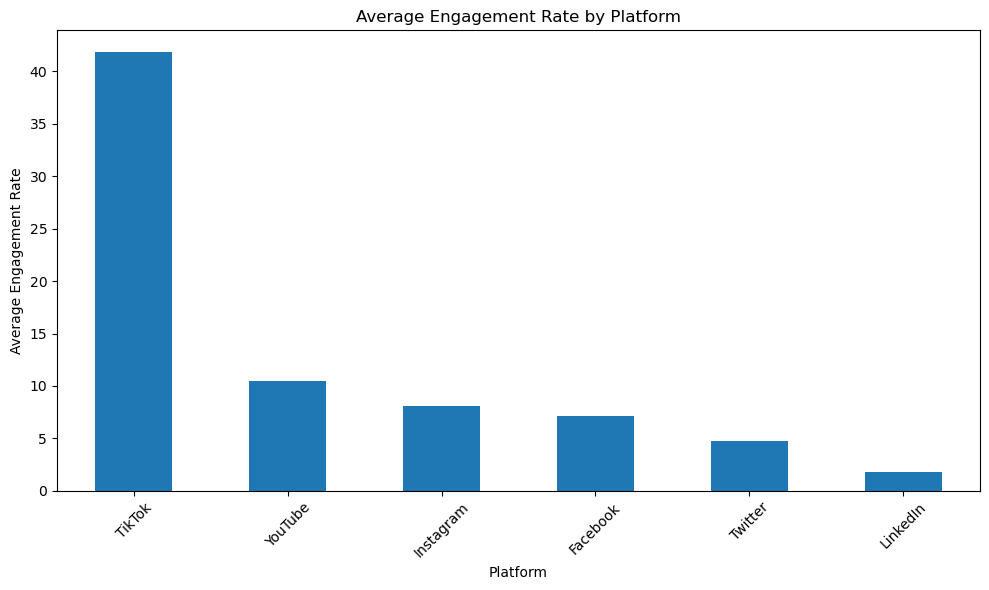

In [97]:
# This chart compares the average engagement rate across social media platforms.
# Platform Engagement Analysis.

platform_engagement = (
    df.groupby("Platform")["Engagement_Rate"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
platform_engagement.plot(kind="bar")

plt.title("Average Engagement Rate by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

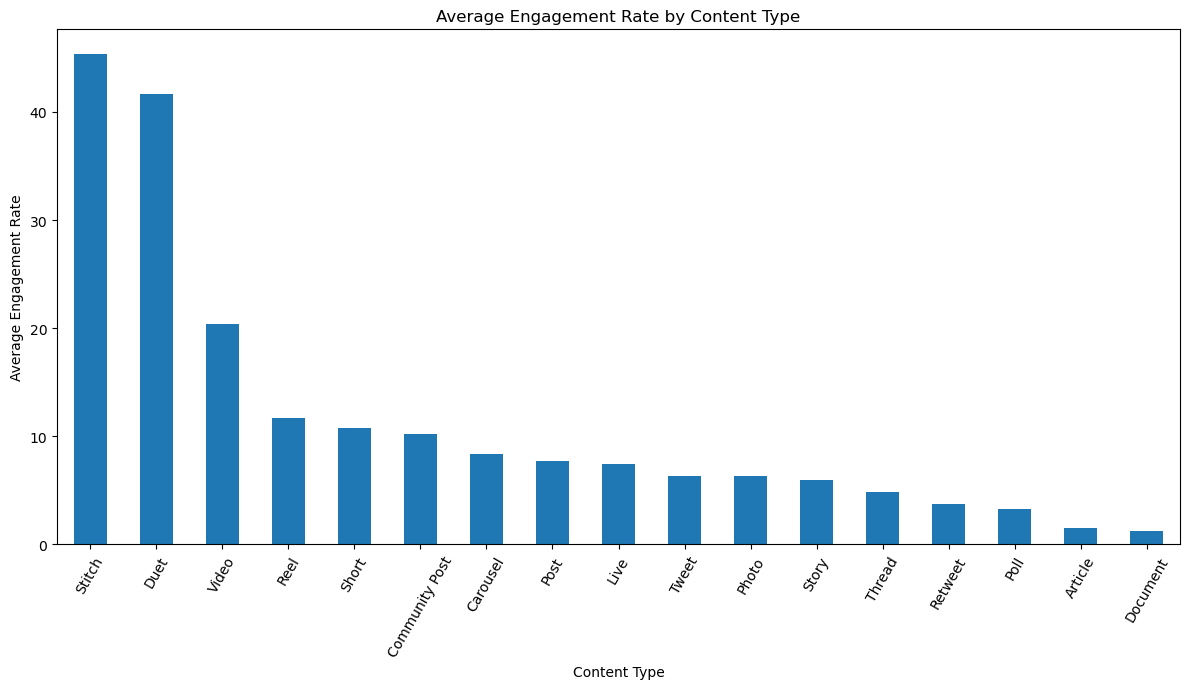

In [98]:
# Content Type Performance
# This chart compares the average engagement rate across different content types.

content_engagement = (
    df.groupby("Content_Type")["Engagement_Rate"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))
content_engagement.plot(kind="bar")

plt.title("Average Engagement Rate by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

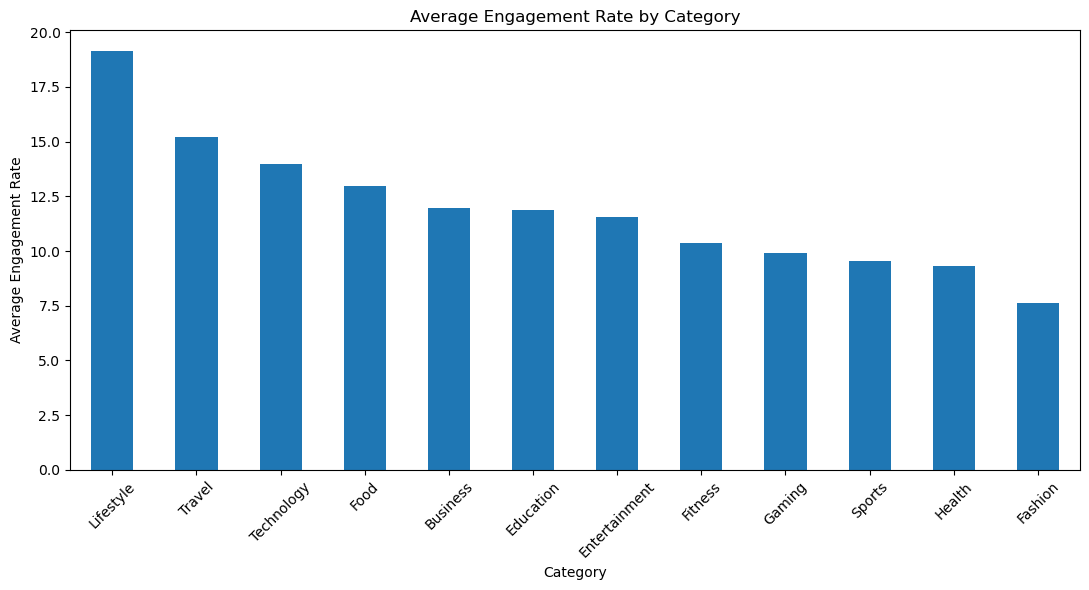

In [99]:
# Engagement by Category
# This chart compares the average engagement rate across different content categories.

category_engagement = (
    df.groupby("Category")["Engagement_Rate"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(11, 6))
category_engagement.plot(kind="bar")

plt.title("Average Engagement Rate by Category")
plt.xlabel("Category")
plt.ylabel("Average Engagement Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

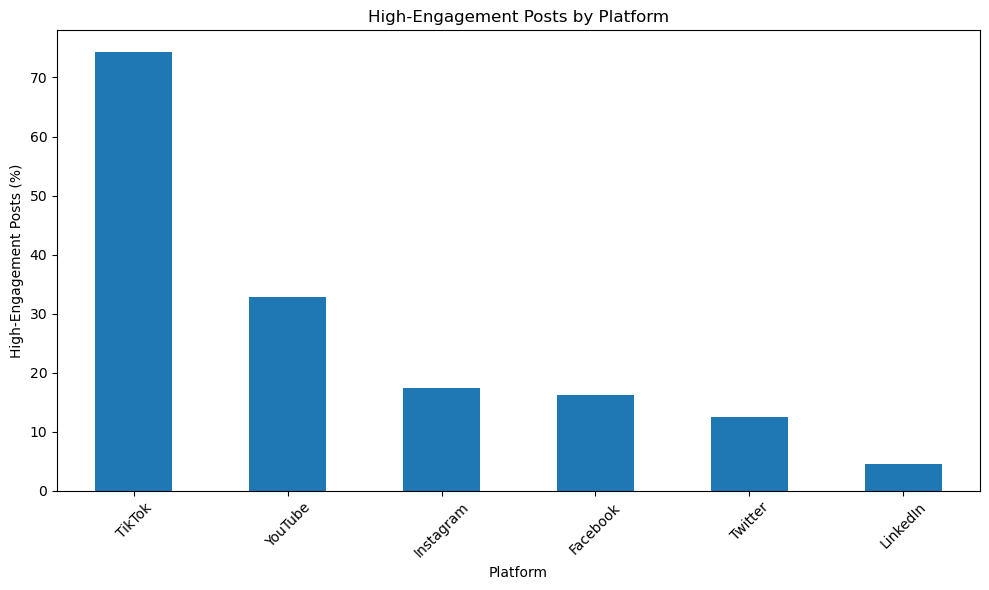

In [100]:
# High-Engagement Rate by Platform
# This chart shows the percentage of posts classified as high engagement for each platform.

platform_high_engagement = (
    df.groupby("Platform")["High_Engagement"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
platform_high_engagement.plot(kind="bar")

plt.title("High-Engagement Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("High-Engagement Posts (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

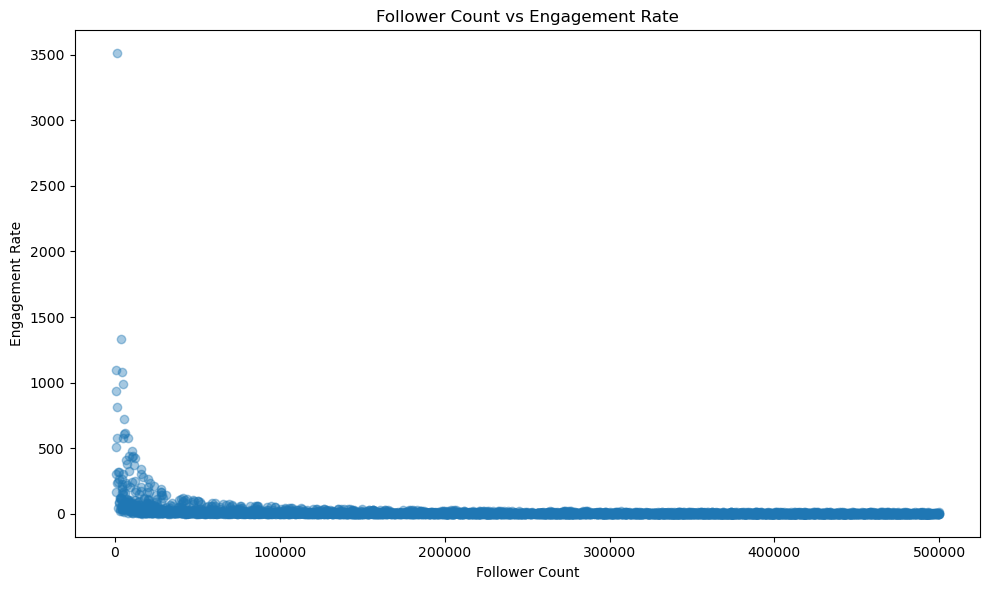

In [101]:
# This scatter plot examines the relationship between follower count and engagement rate.

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Follower_Count"],
    df["Engagement_Rate"],
    alpha=0.4
)

plt.title("Follower Count vs Engagement Rate")
plt.xlabel("Follower Count")
plt.ylabel("Engagement Rate")
plt.tight_layout()
plt.show()

In [102]:
# This creates a simple comparison of the machine learning models used in the project.

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        0.88,
        0.883
    ],
    "ROC_AUC": [
        0.9514,
        0.9515
    ]
})

model_comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.880,0.9514
1,Random Forest,0.883,0.9515


### Model Selection

Two classification models were evaluated: Logistic Regression and Random Forest.

Random Forest was selected as the final model because it achieved slightly better performance:

- Accuracy: 88.3%
- ROC-AUC: 0.9515

The model also achieved approximately 81% recall for the High_Engagement class, correctly identifying most high-engagement posts in the test set.

Five-fold cross-validation produced a mean ROC-AUC of approximately 0.957, indicating consistent model performance across different validation splits.